# Question Classification with Sentence Embeddings — Codex-Style Embedding Model Comparison

1. Use the provided train.csv and test.csv files as-is  
2. Embed each question into a feature vector  
3. Learn the same kind of linear multiclass PyTorch model on top of each embedding space  
4. Compare the two embedding models head-to-head  
5. Identify where each embedding succeeds, where it fails, and which classes each model struggles with  
6. Use confusion matrices, disagreement examples, and coarse-category analysis to diagnose model deficiencies



In [19]:
!pip install -q sentence-transformers torch scikit-learn pandas numpy matplotlib seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [20]:
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sentence_transformers import SentenceTransformer
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


## Step 1: Load and inspect the data

In [21]:
train_df = pd.read_csv('question_classificatrion/question_classification_dataset/train.csv')
test_df = pd.read_csv('question_classificatrion/question_classification_dataset/test.csv')

print("Provided train shape:", train_df.shape)
print("Provided test shape:", test_df.shape)
display(train_df.head())

print("\nNumber of coarse labels:", train_df["label-coarse"].nunique())
print("Number of fine labels:", train_df["label-fine"].nunique())

Provided train shape: (5452, 3)
Provided test shape: (500, 3)


,label-coarse,label-fine,text
0,0,0,How did serfdom develop in and then leave Russ...
1,1,1,What films featured the character Popeye Doyle ?
2,0,0,How can I find a list of celebrities ' real na...
3,1,2,What fowl grabs the spotlight after the Chines...
4,2,3,What is the full form of .com ?



Number of coarse labels: 6
Number of fine labels: 47


## Step 2: Create a holdout split from the provided training set

We keep the provided **test.csv** file as-is and split **train.csv** into
an 80/20 train/holdout split.


In [22]:
focused_df = train_df.copy()

train_split_df, holdout_split_df = train_test_split(
    train_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=train_df["label-fine"],
)
train_split_df = train_split_df.reset_index(drop=True)
holdout_split_df = holdout_split_df.reset_index(drop=True)
test_split_df = test_df.copy().reset_index(drop=True)

print("Train shape:", train_split_df.shape)
print("Holdout shape:", holdout_split_df.shape)
print("Test shape:", test_split_df.shape)

print("\nTrain fine-label distribution:")
display(train_split_df["label-fine"].value_counts().sort_index())

print("\nHoldout fine-label distribution:")
display(holdout_split_df["label-fine"].value_counts().sort_index())

print("\nTest fine-label distribution:")
display(test_split_df["label-fine"].value_counts().sort_index())


Train shape: (2726, 3)
Holdout shape: (2726, 3)
Test shape: (500, 3)

Train fine-label distribution:


label-fine
0     138
1     104
2      56
3      35
4     481
5      95
6      13
7     210
8     109
9      96
10     28
11     33
12    161
13    181
14    367
15      5
16      2
17     51
18     77
19     20
20     47
21     64
22      8
23     51
24     11
25     35
26     21
27     38
28     20
29     31
30      7
31     19
32      6
33      5
34      8
35      5
36     13
37      8
38     13
39      4
40     17
41      4
42      5
43      3
44     13
45      6
46      2
Name: count, dtype: int64


Holdout fine-label distribution:


label-fine
0     138
1     103
2      56
3      35
4     481
5      94
6      12
7     211
8     109
9      95
10     28
11     33
12    160
13    182
14    366
15      4
16      2
17     52
18     78
19     20
20     46
21     65
22      8
23     52
24     10
25     36
26     21
27     37
28     21
29     31
30      6
31     19
32      7
33      5
34      8
35      4
36     13
37      8
38     14
39      5
40     17
41      4
42      6
43      3
44     14
45      5
46      2
Name: count, dtype: int64


Test fine-label distribution:


label-fine
0       2
2      16
3       8
4      55
5       6
6       1
7     123
8      47
9       6
10      2
11      7
12     10
13      9
14     74
17      4
18      3
19     10
20      7
21     18
22      2
23      2
24      3
25      3
26      4
27      8
28     15
29      1
30      5
31      1
33      1
34      1
35      6
37      2
38      3
40     16
41      5
44      4
45      4
46      6
Name: count, dtype: int64

## Step 3: Choose two embedding models

We still use sentence embeddings, but now the embedding becomes the **input vector** `x in R^d` for the linear supervised learner.


In [23]:
embedding_models = [
    "all-MiniLM-L6-v2",
    "paraphrase-MiniLM-L6-v2",
]

X_train_text = train_split_df["text"].tolist()
X_test_text = test_split_df["text"].tolist()


y_train_labels = train_split_df["label-fine"].to_numpy()
y_test_labels = test_split_df["label-fine"].to_numpy()


y_test_coarse = test_split_df["label-coarse"].to_numpy()

class_names = sorted(focused_df["label-fine"].unique().tolist())
class_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

class_names_coarse = sorted(focused_df["label-coarse"].unique().tolist())
fine_to_coarse = (
    focused_df[["label-fine", "label-coarse"]]
    .drop_duplicates()
    .set_index("label-fine")["label-coarse"]
    .to_dict()
)

print("Fine classes:", class_names)
print("Number of fine classes:", len(class_names))
print("Coarse classes:", class_names_coarse)
print("Number of coarse classes:", len(class_names_coarse))


Fine classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
Number of fine classes: 47
Coarse classes: [0, 1, 2, 3, 4, 5]
Number of coarse classes: 6


## Helper functions


In [24]:
def embed_texts(model_name, texts):
    # Load the sentence-transformer model and encode the input texts.
    model = SentenceTransformer(model_name)
    # Encode all texts into a 2D numpy array of embeddings.
    embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    return embeddings


def labels_to_index(labels, class_to_idx):
    # Map each label string to its integer class index.
    return np.array([class_to_idx[label] for label in labels], dtype=np.int64)


def one_hot_encode(label_indices, num_classes):
    # Build one-hot rows for each class index.
    return np.eye(num_classes, dtype=np.float32)[label_indices]


def make_multiclass_tensors(X_np, y_labels, class_to_idx):
    # Convert labels to indices and one-hot encode them for training.
    y_idx = labels_to_index(y_labels, class_to_idx)
    y_onehot = one_hot_encode(y_idx, len(class_to_idx))

    # Convert embeddings and one-hot labels into float tensors.
    X_tensor = torch.tensor(X_np, dtype=torch.float32).reshape(X_np.shape)
    Y_onehot_tensor = torch.tensor(y_onehot, dtype=torch.float32).reshape(y_onehot.shape)

    # Return tensors plus raw class indices for metrics.
    return X_tensor, Y_onehot_tensor, y_idx


def model_fit_pytorch(x_train, y_train, model, loss_criterion=None, epochs=1000, lr=0.01):
    # Default to MSE loss for one-hot regression-style training.
    if loss_criterion is None:
        loss_criterion = nn.MSELoss()
    # Use simple SGD for optimization.
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Track training loss over epochs for plotting.
    loss_history = []

    # Standard training loop: forward, loss, backward, step.
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass and loss computation.
        y_pred = model(x_train)
        loss = loss_criterion(y_pred, y_train)

        # Backpropagation and parameter update.
        loss.backward()
        optimizer.step()

        # Store loss for later visualization.
        loss_history.append(loss.item())

        if (epoch + 1) % 200 == 0:
            print(f"Epoch {epoch + 1}/{epochs} - loss: {loss.item():.6f}")

    return model, loss_history


def pytorch_model_multiclass_inference(model, X_tensor):
    # Run the model in eval mode and return scores plus class indices.
    model.eval()
    with torch.no_grad():
        # Raw model outputs for each class.
        Y_pred = model(X_tensor)
        # Take argmax to get predicted class index.
        pred_idx = torch.argmax(Y_pred, dim=1).detach().cpu().numpy()
    return Y_pred.detach().cpu().numpy(), pred_idx



def plot_conf_mat(y_true, y_pred, labels, title, save_path=None):
    # Compute a row-normalized confusion matrix in percent.
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true") * 100

    # Create a heatmap-style plot.
    fig, ax = plt.subplots(figsize=(max(7, 0.6 * len(labels)), max(6, 0.55 * len(labels))))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=100)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Label axes with class names.
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Annotate each cell with its percentage.
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{cm[i, j]:.1f}", ha="center", va="center", color="black")

    # Add labels, title, and gridlines for readability.
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True (row %)")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xticks(np.arange(len(labels) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(labels) + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()

    # Optionally save the figure to disk.
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


def build_linear_multiclass_model(input_dim, output_dim):
    # Create a single-layer linear classifier for multiclass prediction.
    return nn.Sequential(nn.Linear(input_dim, output_dim))


def train_one_embedding_pipeline(model_name, X_train_text, X_test_text, y_train_labels, y_test_labels, class_to_idx, class_names, epochs=2000, lr=0.02):
    # End-to-end pipeline: embed text, train classifier, and collect predictions.
    print(f"===== Running {model_name} =====")

    # Generate embeddings for each data split.
    X_train_emb = embed_texts(model_name, X_train_text)
    X_test_emb = embed_texts(model_name, X_test_text)
    # Convert embeddings/labels into PyTorch tensors.
    X_train_tensor, Y_train_onehot_tensor, _ = make_multiclass_tensors(X_train_emb, y_train_labels, class_to_idx)
    X_test_tensor, _, y_test_idx = make_multiclass_tensors(X_test_emb, y_test_labels, class_to_idx)
    # Build a linear classifier sized to the embedding dimension.
    linear_model = build_linear_multiclass_model(
        input_dim=X_train_tensor.shape[1],
        output_dim=Y_train_onehot_tensor.shape[1]
    )

    # Train the model on the training split.
    trained_model, loss_history = model_fit_pytorch(
        X_train_tensor,
        Y_train_onehot_tensor,
        linear_model,
        epochs=epochs,
        lr=lr
    )

    # Predict fine labels on the test split.
    _, test_pred_idx = pytorch_model_multiclass_inference(trained_model, X_test_tensor)
    test_pred_labels = np.array([class_names[i] for i in test_pred_idx], dtype=object)

    # Collect outputs for later evaluation and plotting.
    artifacts = {
        "model_name": model_name,
        "trained_model": trained_model,
        "loss_history": loss_history,
        "y_test_idx": y_test_idx,
        "test_pred_idx": test_pred_idx,
        "test_pred_labels": test_pred_labels,
    }
    return artifacts


## Step 4: Embed the data and train the linear multiclass PyTorch model


In [25]:
artifacts = {}

for model_name in embedding_models:
    epochs = 20000 if model_name == "paraphrase-MiniLM-L6-v2" else 80000
    run_artifacts = train_one_embedding_pipeline(
        model_name=model_name,
        X_train_text=X_train_text,
        X_test_text=X_test_text,
        y_train_labels=y_train_labels,
        y_test_labels=y_test_labels,
        class_to_idx=class_to_idx,
        class_names=class_names,
        epochs=epochs,
        lr=1,
    )
    artifacts[model_name] = run_artifacts


===== Running all-MiniLM-L6-v2 =====


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 200/20000 - loss: 0.015636
Epoch 400/20000 - loss: 0.013606
Epoch 600/20000 - loss: 0.012779
Epoch 800/20000 - loss: 0.012286
Epoch 1000/20000 - loss: 0.011947
Epoch 1200/20000 - loss: 0.011694
Epoch 1400/20000 - loss: 0.011498
Epoch 1600/20000 - loss: 0.011340
Epoch 1800/20000 - loss: 0.011211
Epoch 2000/20000 - loss: 0.011103
Epoch 2200/20000 - loss: 0.011011
Epoch 2400/20000 - loss: 0.010933
Epoch 2600/20000 - loss: 0.010865
Epoch 2800/20000 - loss: 0.010806
Epoch 3000/20000 - loss: 0.010754
Epoch 3200/20000 - loss: 0.010708
Epoch 3400/20000 - loss: 0.010667
Epoch 3600/20000 - loss: 0.010631
Epoch 3800/20000 - loss: 0.010598
Epoch 4000/20000 - loss: 0.010569
Epoch 4200/20000 - loss: 0.010542
Epoch 4400/20000 - loss: 0.010518
Epoch 4600/20000 - loss: 0.010496
Epoch 4800/20000 - loss: 0.010476
Epoch 5000/20000 - loss: 0.010458
Epoch 5200/20000 - loss: 0.010441
Epoch 5400/20000 - loss: 0.010426
Epoch 5600/20000 - loss: 0.010412
Epoch 5800/20000 - loss: 0.010399
Epoch 6000/20000 -

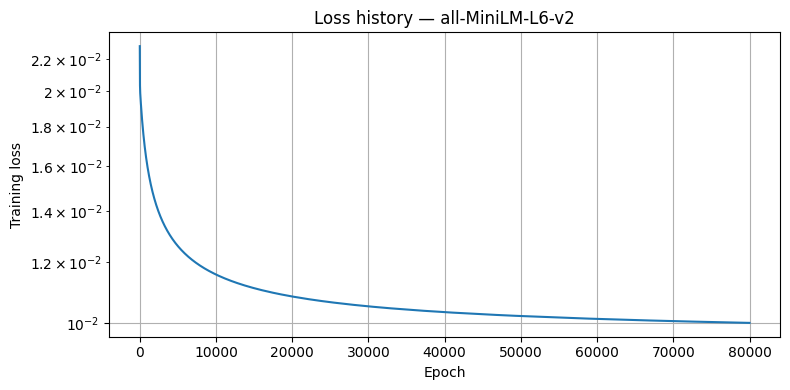

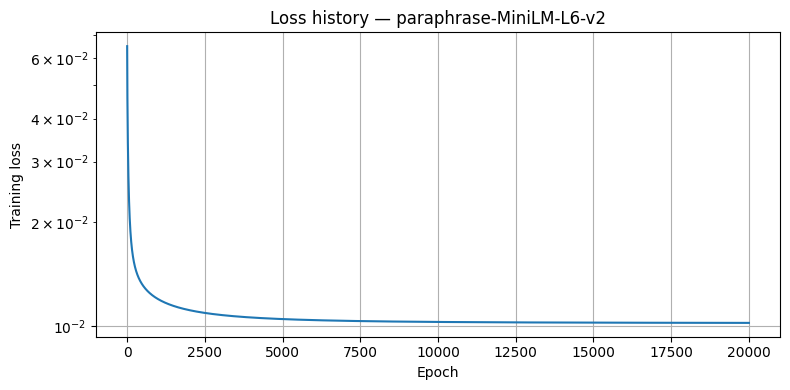

In [26]:
# Plot training loss history (log scale) for each embedding model
for model_name in embedding_models:
    loss_history = artifacts[model_name]["loss_history"]
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(loss_history)), loss_history)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"Loss history — {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Step 5: Baseline head-to-head comparison

Now that both embedding models have been trained using the same linear PyTorch classifier pipeline, we compare them in several ways:

- overall metrics on train / test
- fine-label confusion matrices
- per-class F1 differences
- disagreement examples on the same test questions

This lets us separate **overall performance** from **where each embedding succeeds or fails**.



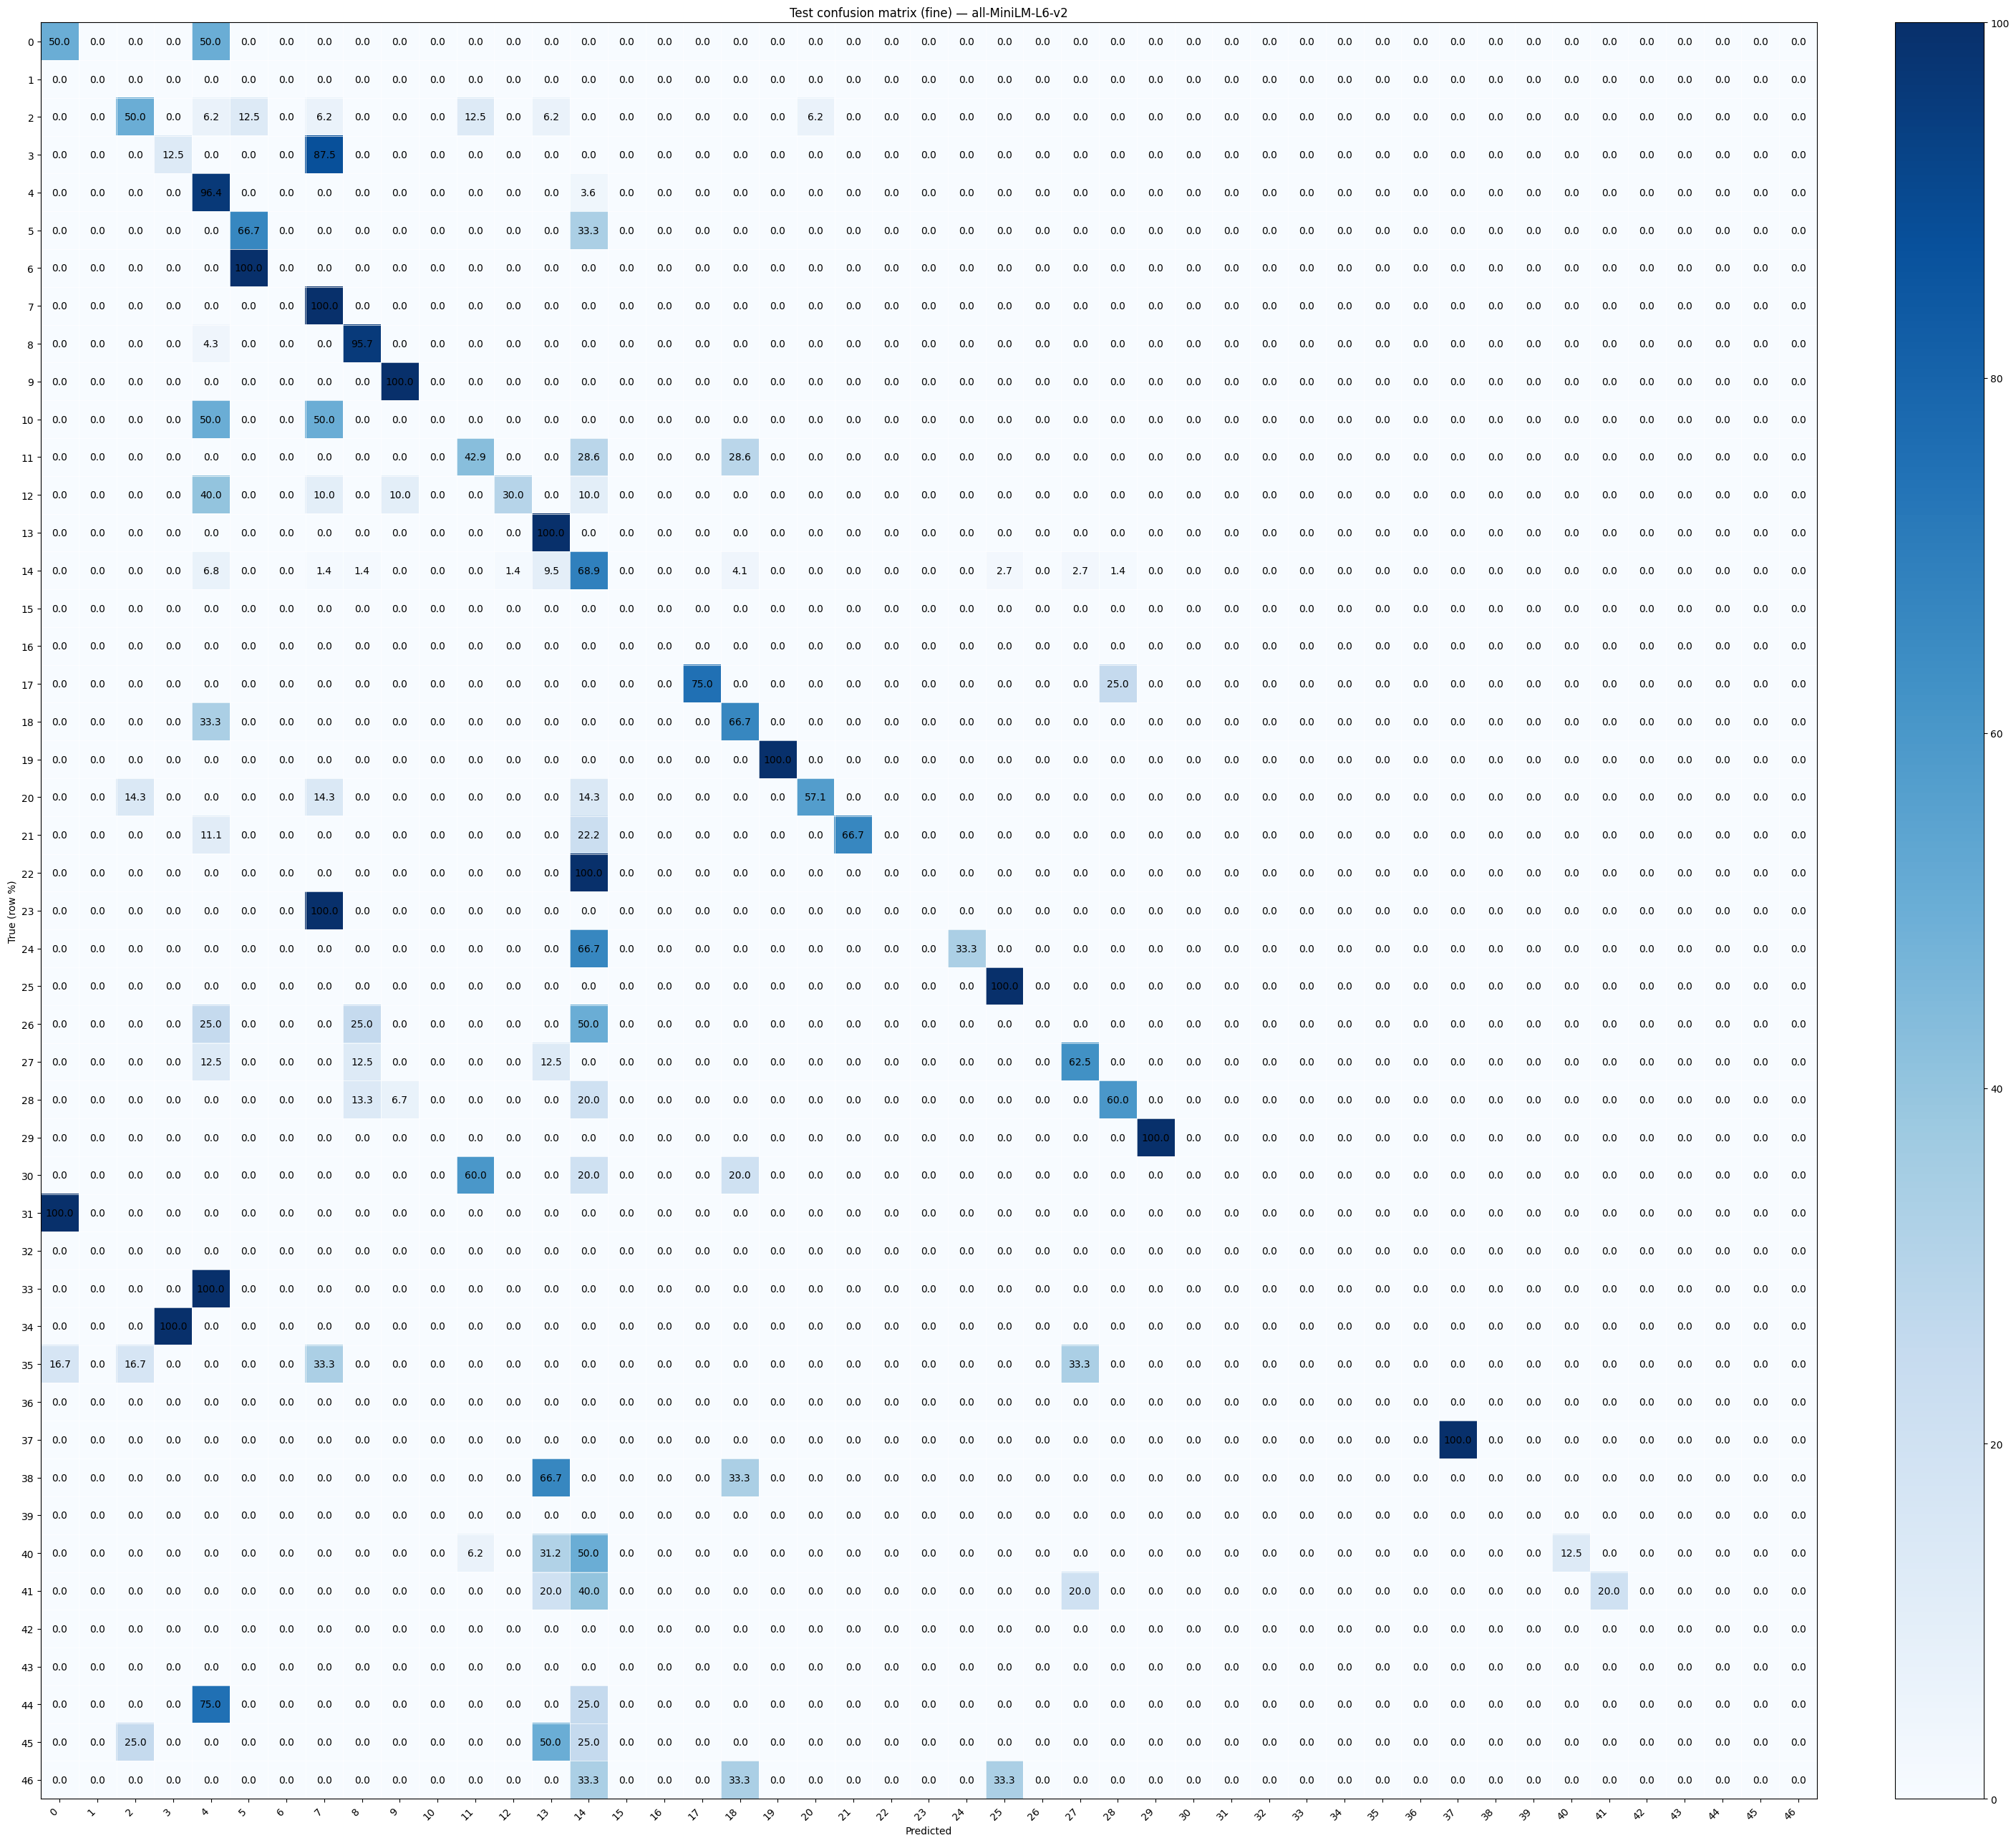

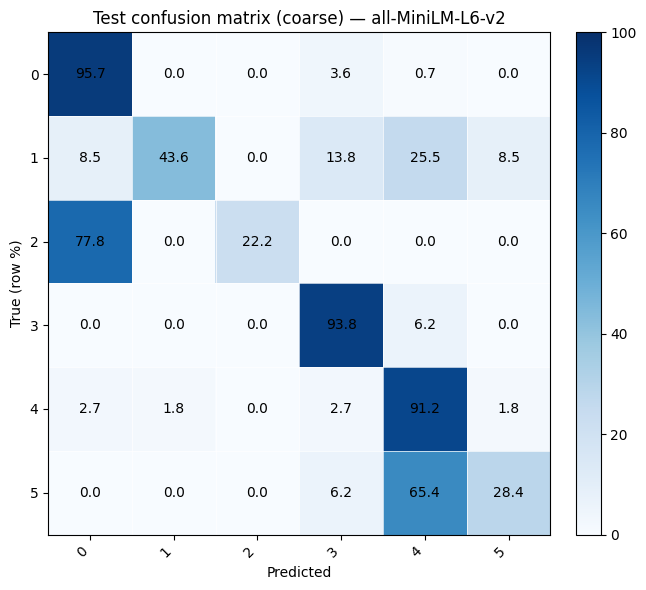

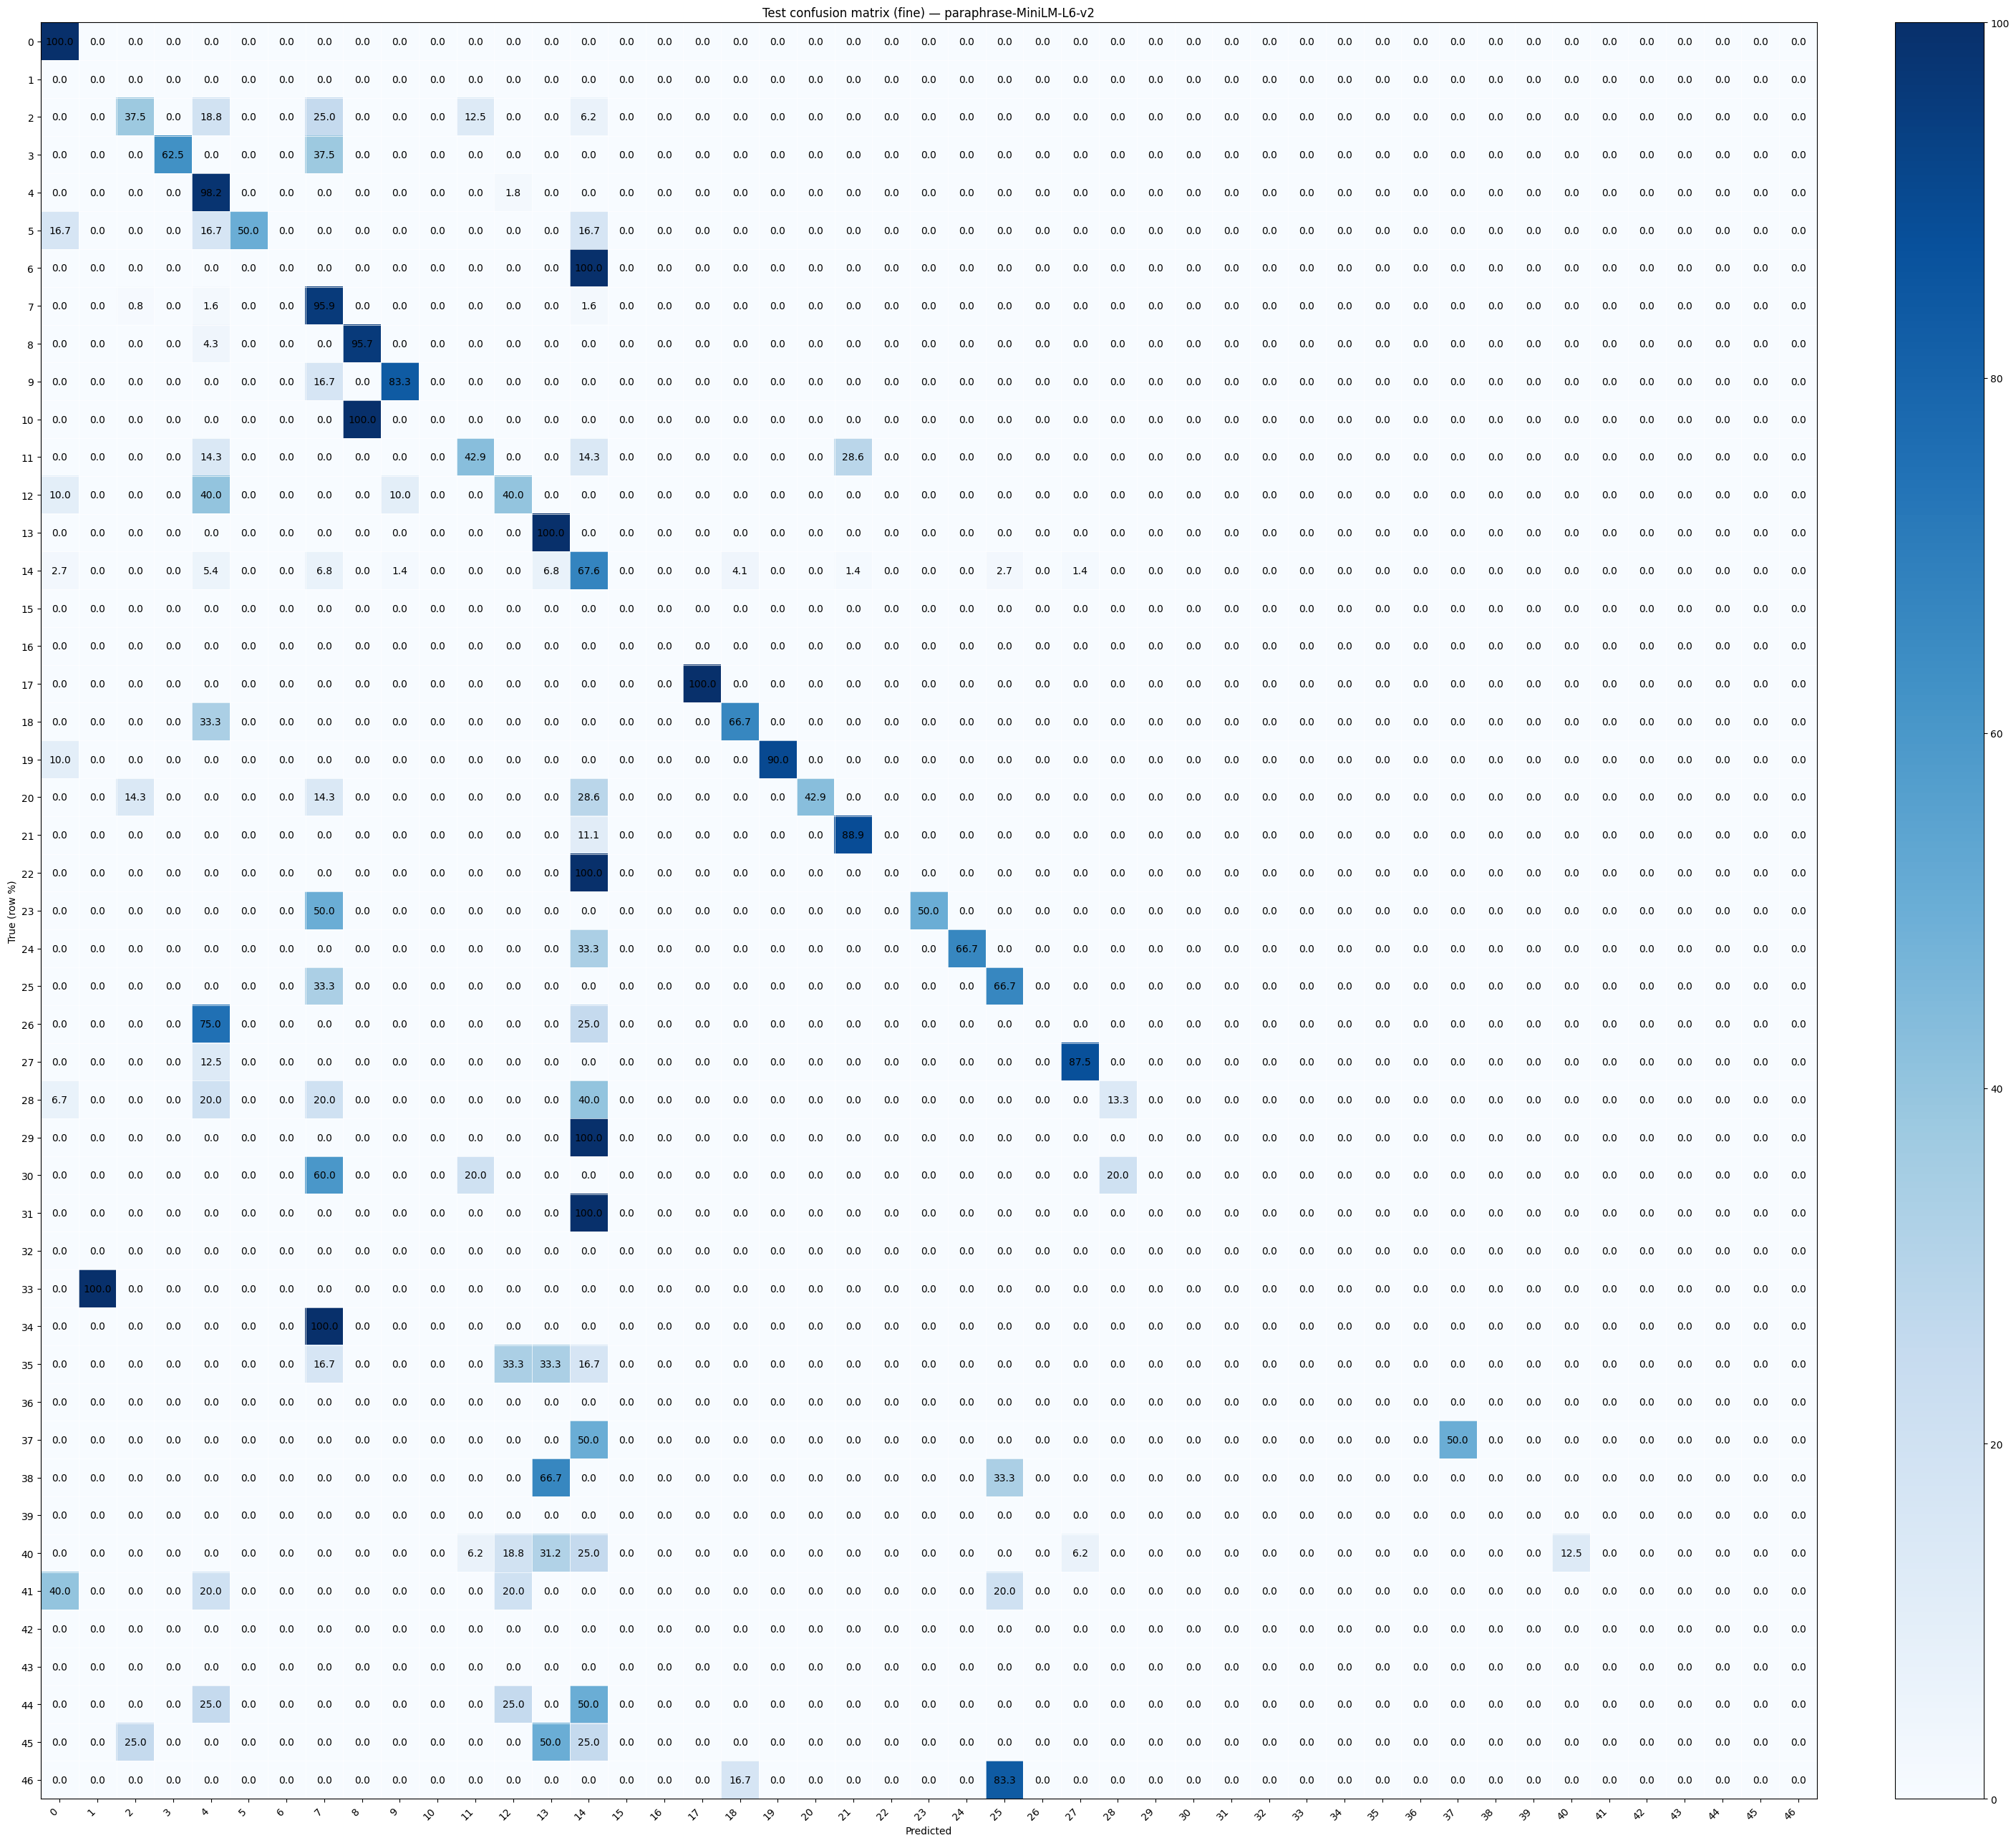

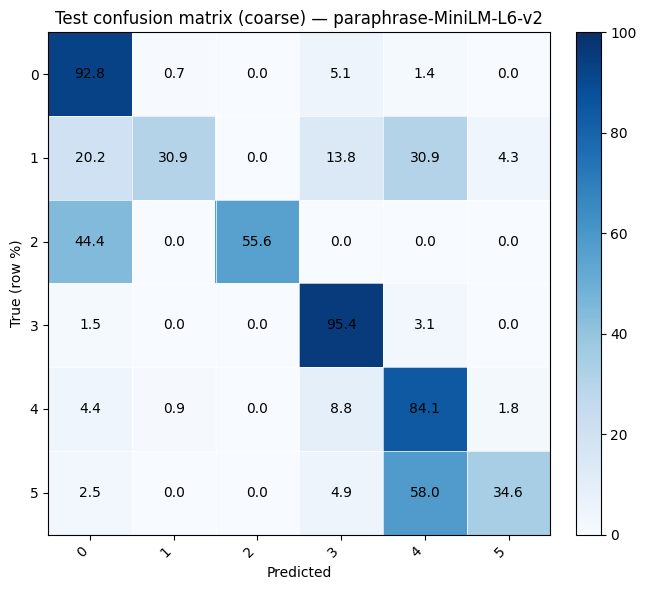

In [27]:
matrices_dir = Path("matrices")

for model_name in embedding_models:
    plot_conf_mat(
        artifacts[model_name]["y_test_idx"],
        artifacts[model_name]["test_pred_idx"],
        labels=np.arange(len(class_names)),
        title=f"Test confusion matrix (fine) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_fine.png"
    )

    # coarse view: map predicted fine label -> coarse label
    test_pred_coarse = pd.Series(artifacts[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()

    plot_conf_mat(
        y_test_coarse,
        test_pred_coarse,
        labels=class_names_coarse,
        title=f"Test confusion matrix (coarse) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_coarse.png"
    )

In [28]:
# Download All matrices
from pathlib import Path
import shutil

src_dir = Path('matrices')
dst_dir = Path('new_matrices')
dst_dir.mkdir(parents=True, exist_ok=True)

# newCodeBase writes baseline_{model}_fine/coarse.png -> 4 files total
patterns = ["baseline_*_fine.png", "baseline_*_coarse.png"]
copied = 0
for pattern in patterns:
    for img_path in src_dir.glob(pattern):
        shutil.copy2(img_path, dst_dir / img_path.name)
        copied += 1

print(f'Copied {copied} files to {dst_dir}')


Copied 4 files to new_matrices


In [29]:
# Combine the 4 matrices into a single PDF
from pathlib import Path
from PIL import Image

src_dir = Path('new_matrices')
pdf_path = src_dir / 'combined_matrices.pdf'

image_paths = sorted(src_dir.glob('baseline_*_*.png'))
if not image_paths:
    raise FileNotFoundError('No matrices found in new_matrices')

images = [Image.open(p).convert('RGB') for p in image_paths]
images[0].save(pdf_path, save_all=True, append_images=images[1:])

print(f'Wrote {pdf_path} with {len(images)} pages')


Wrote new_matrices/combined_matrices.pdf with 4 pages


In [30]:
# Compare accuracy scores for each model on fine and coarse labels
accuracy_rows = []
for model_name in embedding_models:
    fine_acc = accuracy_score(
        artifacts[model_name]["y_test_idx"],
        artifacts[model_name]["test_pred_idx"]
    )
    test_pred_coarse = pd.Series(artifacts[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()
    coarse_acc = accuracy_score(y_test_coarse, test_pred_coarse)
    accuracy_rows.append({
        "model": model_name,
        "fine_accuracy": fine_acc,
        "coarse_accuracy": coarse_acc,
    })

accuracy_df = pd.DataFrame(accuracy_rows).sort_values("fine_accuracy", ascending=False)
accuracy_df


,model,fine_accuracy,coarse_accuracy
0,all-MiniLM-L6-v2,0.724,0.724
1,paraphrase-MiniLM-L6-v2,0.710,0.694


## Step 9: Add targeted holdout samples back into training

We upsample the coarse labels 1, 2, and 5 by moving 10% of each class
from the holdout set into the training set. This keeps the test set unchanged
and reduces the holdout size accordingly.


In [31]:
# Add 10% more samples (per coarse label) from holdout into training.
target_coarse_labels = [1, 2, 5]
train_coarse_counts = train_split_df["label-coarse"].value_counts()

added_rows = []
for coarse_label in target_coarse_labels:
    desired_increase = int(np.ceil(train_coarse_counts.get(coarse_label, 0) * 0.10))
    if desired_increase <= 0:
        continue
    candidates = holdout_split_df[holdout_split_df["label-coarse"] == coarse_label]
    take_n = min(desired_increase, len(candidates))
    if take_n == 0:
        continue
    added_rows.append(candidates.sample(n=take_n, random_state=RANDOM_STATE))

if added_rows:
    added_df = pd.concat(added_rows)
else:
    added_df = holdout_split_df.head(0).copy()

train_split_df = pd.concat([train_split_df, added_df], ignore_index=True).reset_index(drop=True)
holdout_split_df = holdout_split_df.drop(added_df.index).reset_index(drop=True)

print("Added rows by coarse label:")
display(added_df["label-coarse"].value_counts().sort_index())

print("\nUpdated train coarse-label distribution:")
display(train_split_df["label-coarse"].value_counts().sort_index())

print("\nUpdated holdout coarse-label distribution:")
display(holdout_split_df["label-coarse"].value_counts().sort_index())


Added rows by coarse label:


label-coarse
1    63
2     5
5    42
Name: count, dtype: int64


Updated train coarse-label distribution:


label-coarse
0    584
1    687
2     48
3    610
4    446
5    461
Name: count, dtype: int64


Updated holdout coarse-label distribution:


label-coarse
0    578
1    563
2     38
3    613
4    450
5    374
Name: count, dtype: int64

## Step 10: Retrain after holdout augmentation

We retrain the embedding + linear model pipeline using the updated training set
and re-evaluate on the original test set.


In [32]:
X_train_text = train_split_df["text"].tolist()
y_train_labels = train_split_df["label-fine"].to_numpy()

artifacts_augmented = {}

for model_name in embedding_models:
    epochs = 20000 if model_name == "paraphrase-MiniLM-L6-v2" else 80000
    run_artifacts = train_one_embedding_pipeline(
        model_name=model_name,
        X_train_text=X_train_text,
        X_test_text=X_test_text,
        y_train_labels=y_train_labels,
        y_test_labels=y_test_labels,
        class_to_idx=class_to_idx,
        class_names=class_names,
        epochs=epochs,
        lr=0.3,
    )
    artifacts_augmented[model_name] = run_artifacts


===== Running all-MiniLM-L6-v2 =====


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 200/20000 - loss: 0.023296
Epoch 400/20000 - loss: 0.018185
Epoch 600/20000 - loss: 0.016217
Epoch 800/20000 - loss: 0.015163
Epoch 1000/20000 - loss: 0.014491
Epoch 1200/20000 - loss: 0.014015
Epoch 1400/20000 - loss: 0.013654
Epoch 1600/20000 - loss: 0.013367
Epoch 1800/20000 - loss: 0.013131
Epoch 2000/20000 - loss: 0.012932
Epoch 2200/20000 - loss: 0.012760
Epoch 2400/20000 - loss: 0.012610
Epoch 2600/20000 - loss: 0.012477
Epoch 2800/20000 - loss: 0.012358
Epoch 3000/20000 - loss: 0.012251
Epoch 3200/20000 - loss: 0.012154
Epoch 3400/20000 - loss: 0.012066
Epoch 3600/20000 - loss: 0.011985
Epoch 3800/20000 - loss: 0.011910
Epoch 4000/20000 - loss: 0.011840
Epoch 4200/20000 - loss: 0.011776
Epoch 4400/20000 - loss: 0.011716
Epoch 4600/20000 - loss: 0.011661
Epoch 4800/20000 - loss: 0.011608
Epoch 5000/20000 - loss: 0.011559
Epoch 5200/20000 - loss: 0.011513
Epoch 5400/20000 - loss: 0.011470
Epoch 5600/20000 - loss: 0.011429
Epoch 5800/20000 - loss: 0.011391
Epoch 6000/20000 -

## Step 11: Confusion matrices after holdout augmentation

We visualize fine and coarse confusion matrices for the retrained models.


In [33]:
# Recompute accuracy after augmentation
accuracy_rows = []
for model_name in embedding_models:
    fine_acc = accuracy_score(
        artifacts_augmented[model_name]["y_test_idx"],
        artifacts_augmented[model_name]["test_pred_idx"]
    )
    test_pred_coarse = pd.Series(artifacts_augmented[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()
    coarse_acc = accuracy_score(y_test_coarse, test_pred_coarse)
    accuracy_rows.append({
        "model": model_name,
        "fine_accuracy": fine_acc,
        "coarse_accuracy": coarse_acc,
    })

accuracy_df_augmented = pd.DataFrame(accuracy_rows).sort_values("fine_accuracy", ascending=False)
accuracy_df_augmented

,model,fine_accuracy,coarse_accuracy
0,all-MiniLM-L6-v2,0.716,0.728
1,paraphrase-MiniLM-L6-v2,0.706,0.696


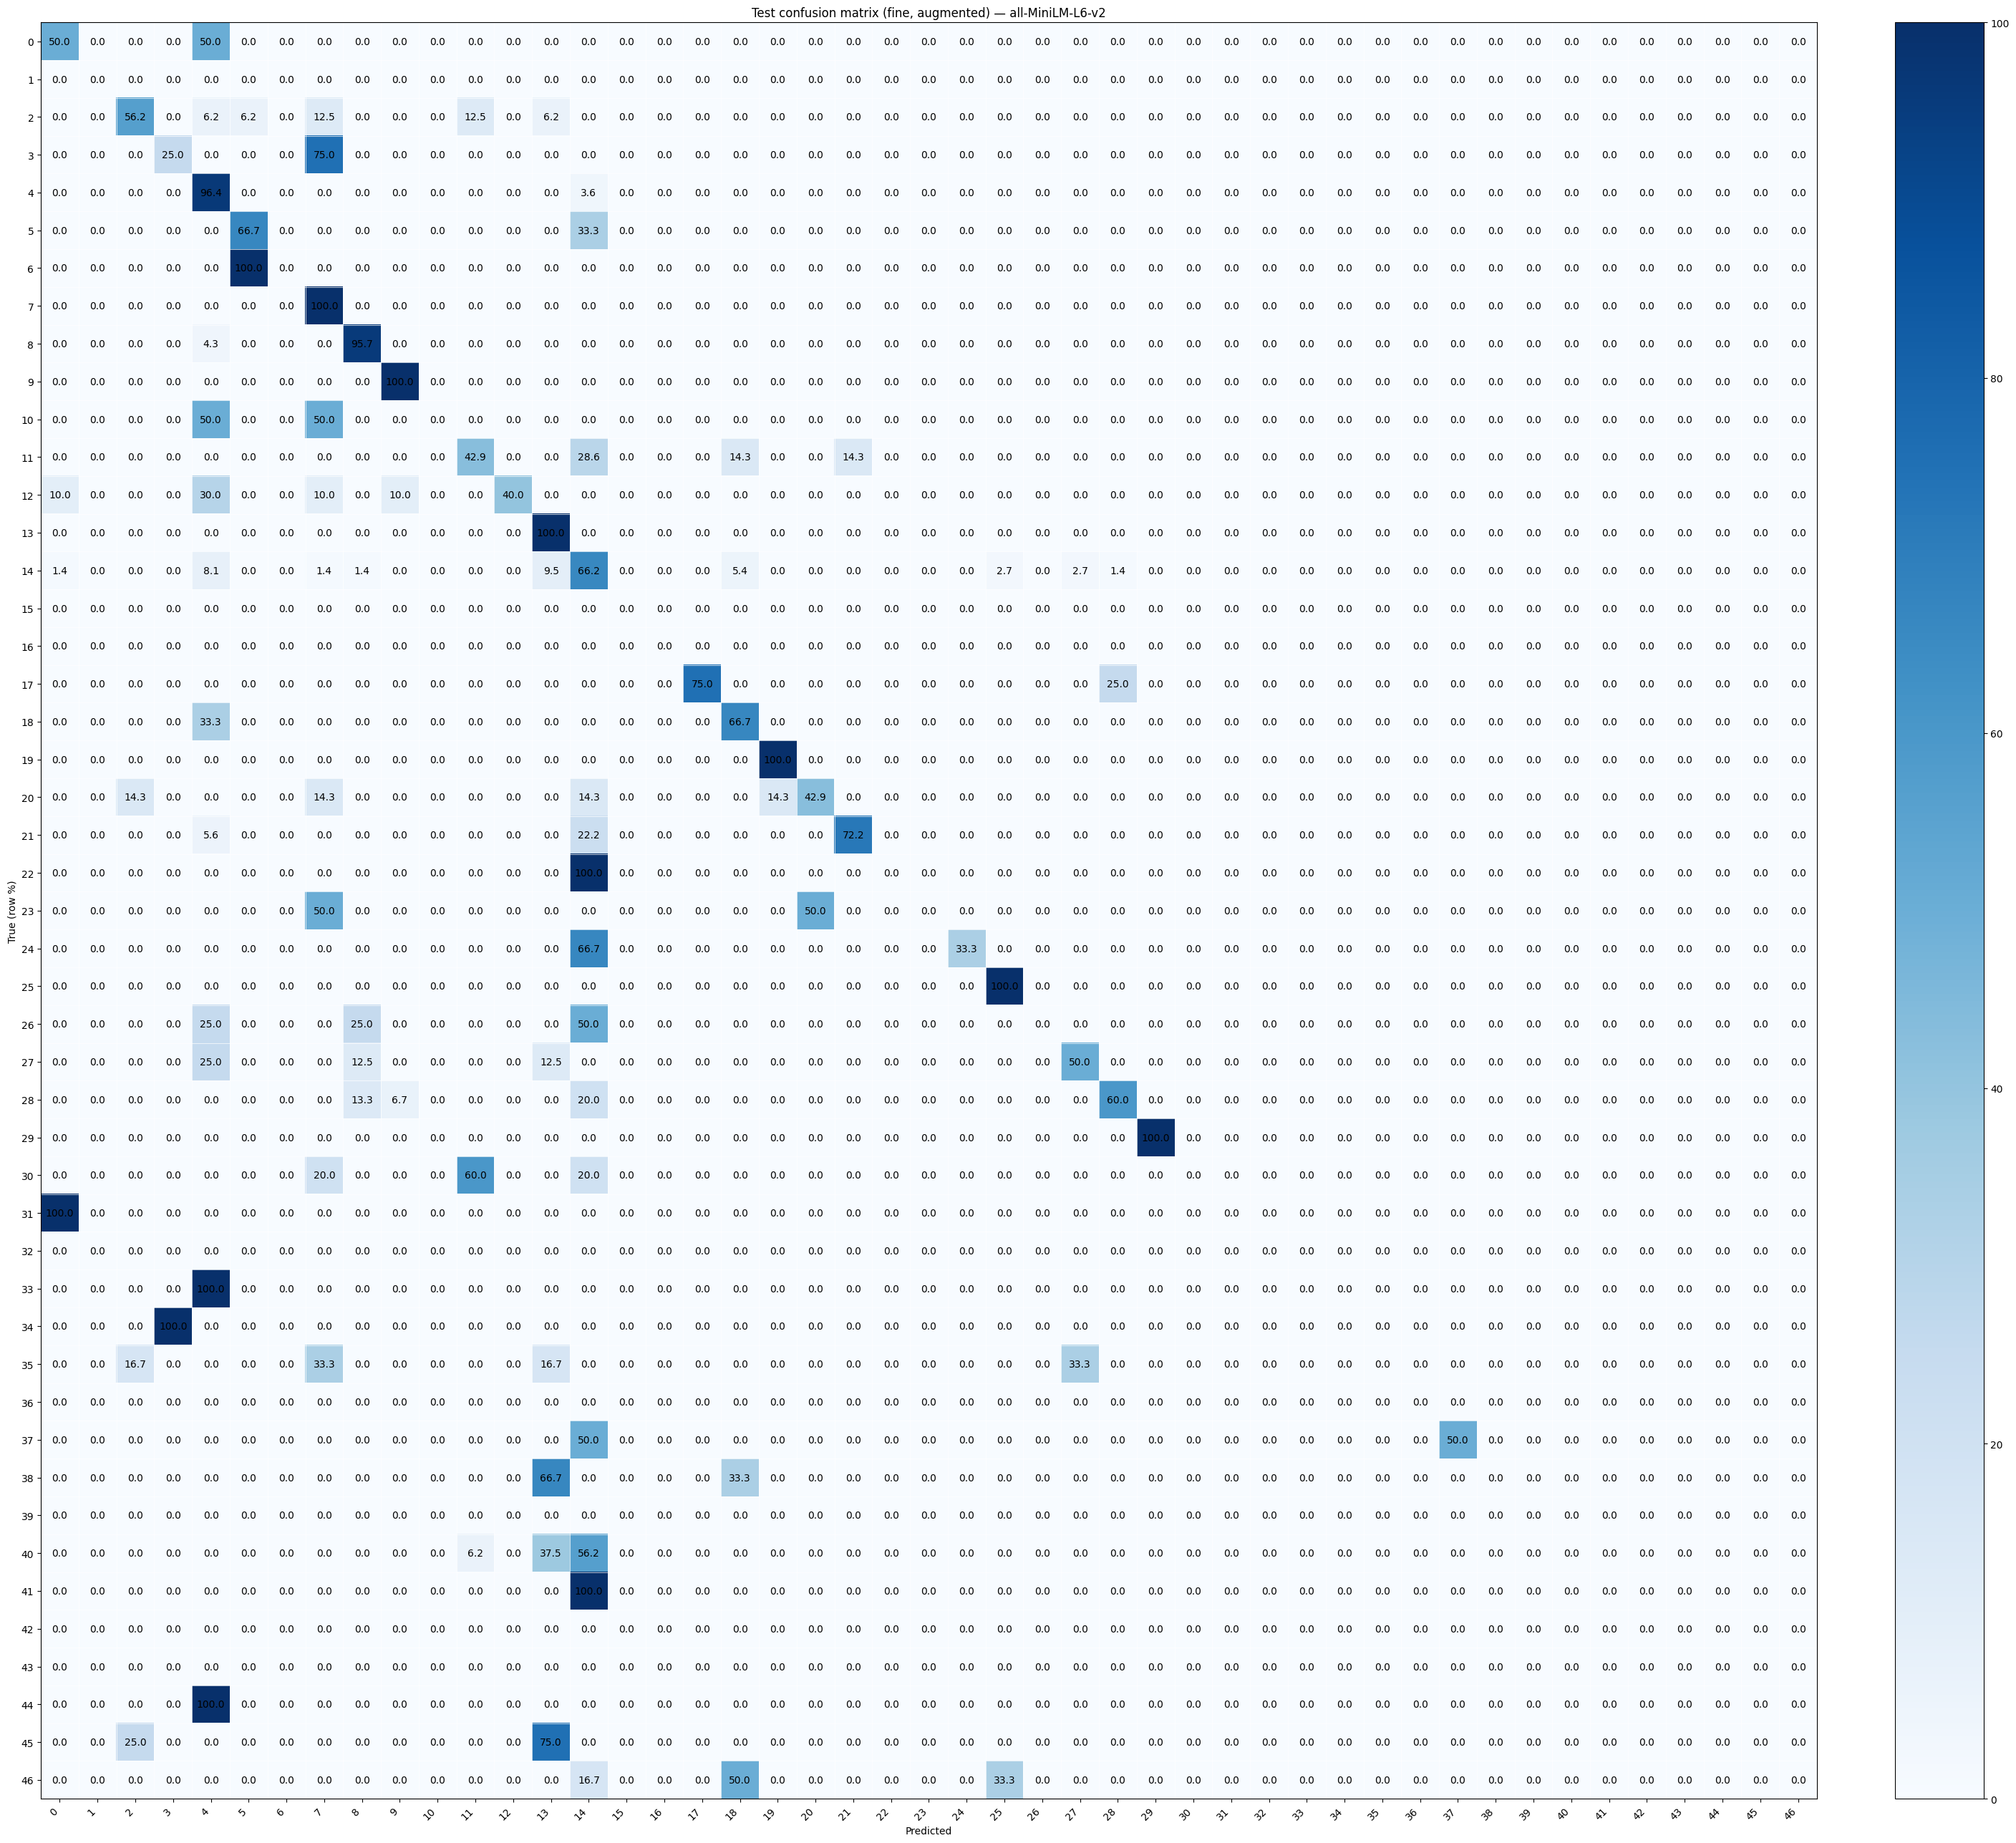

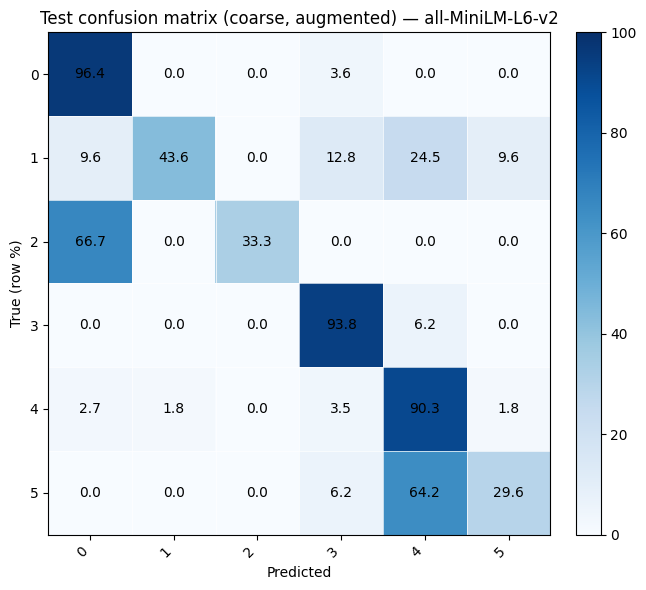

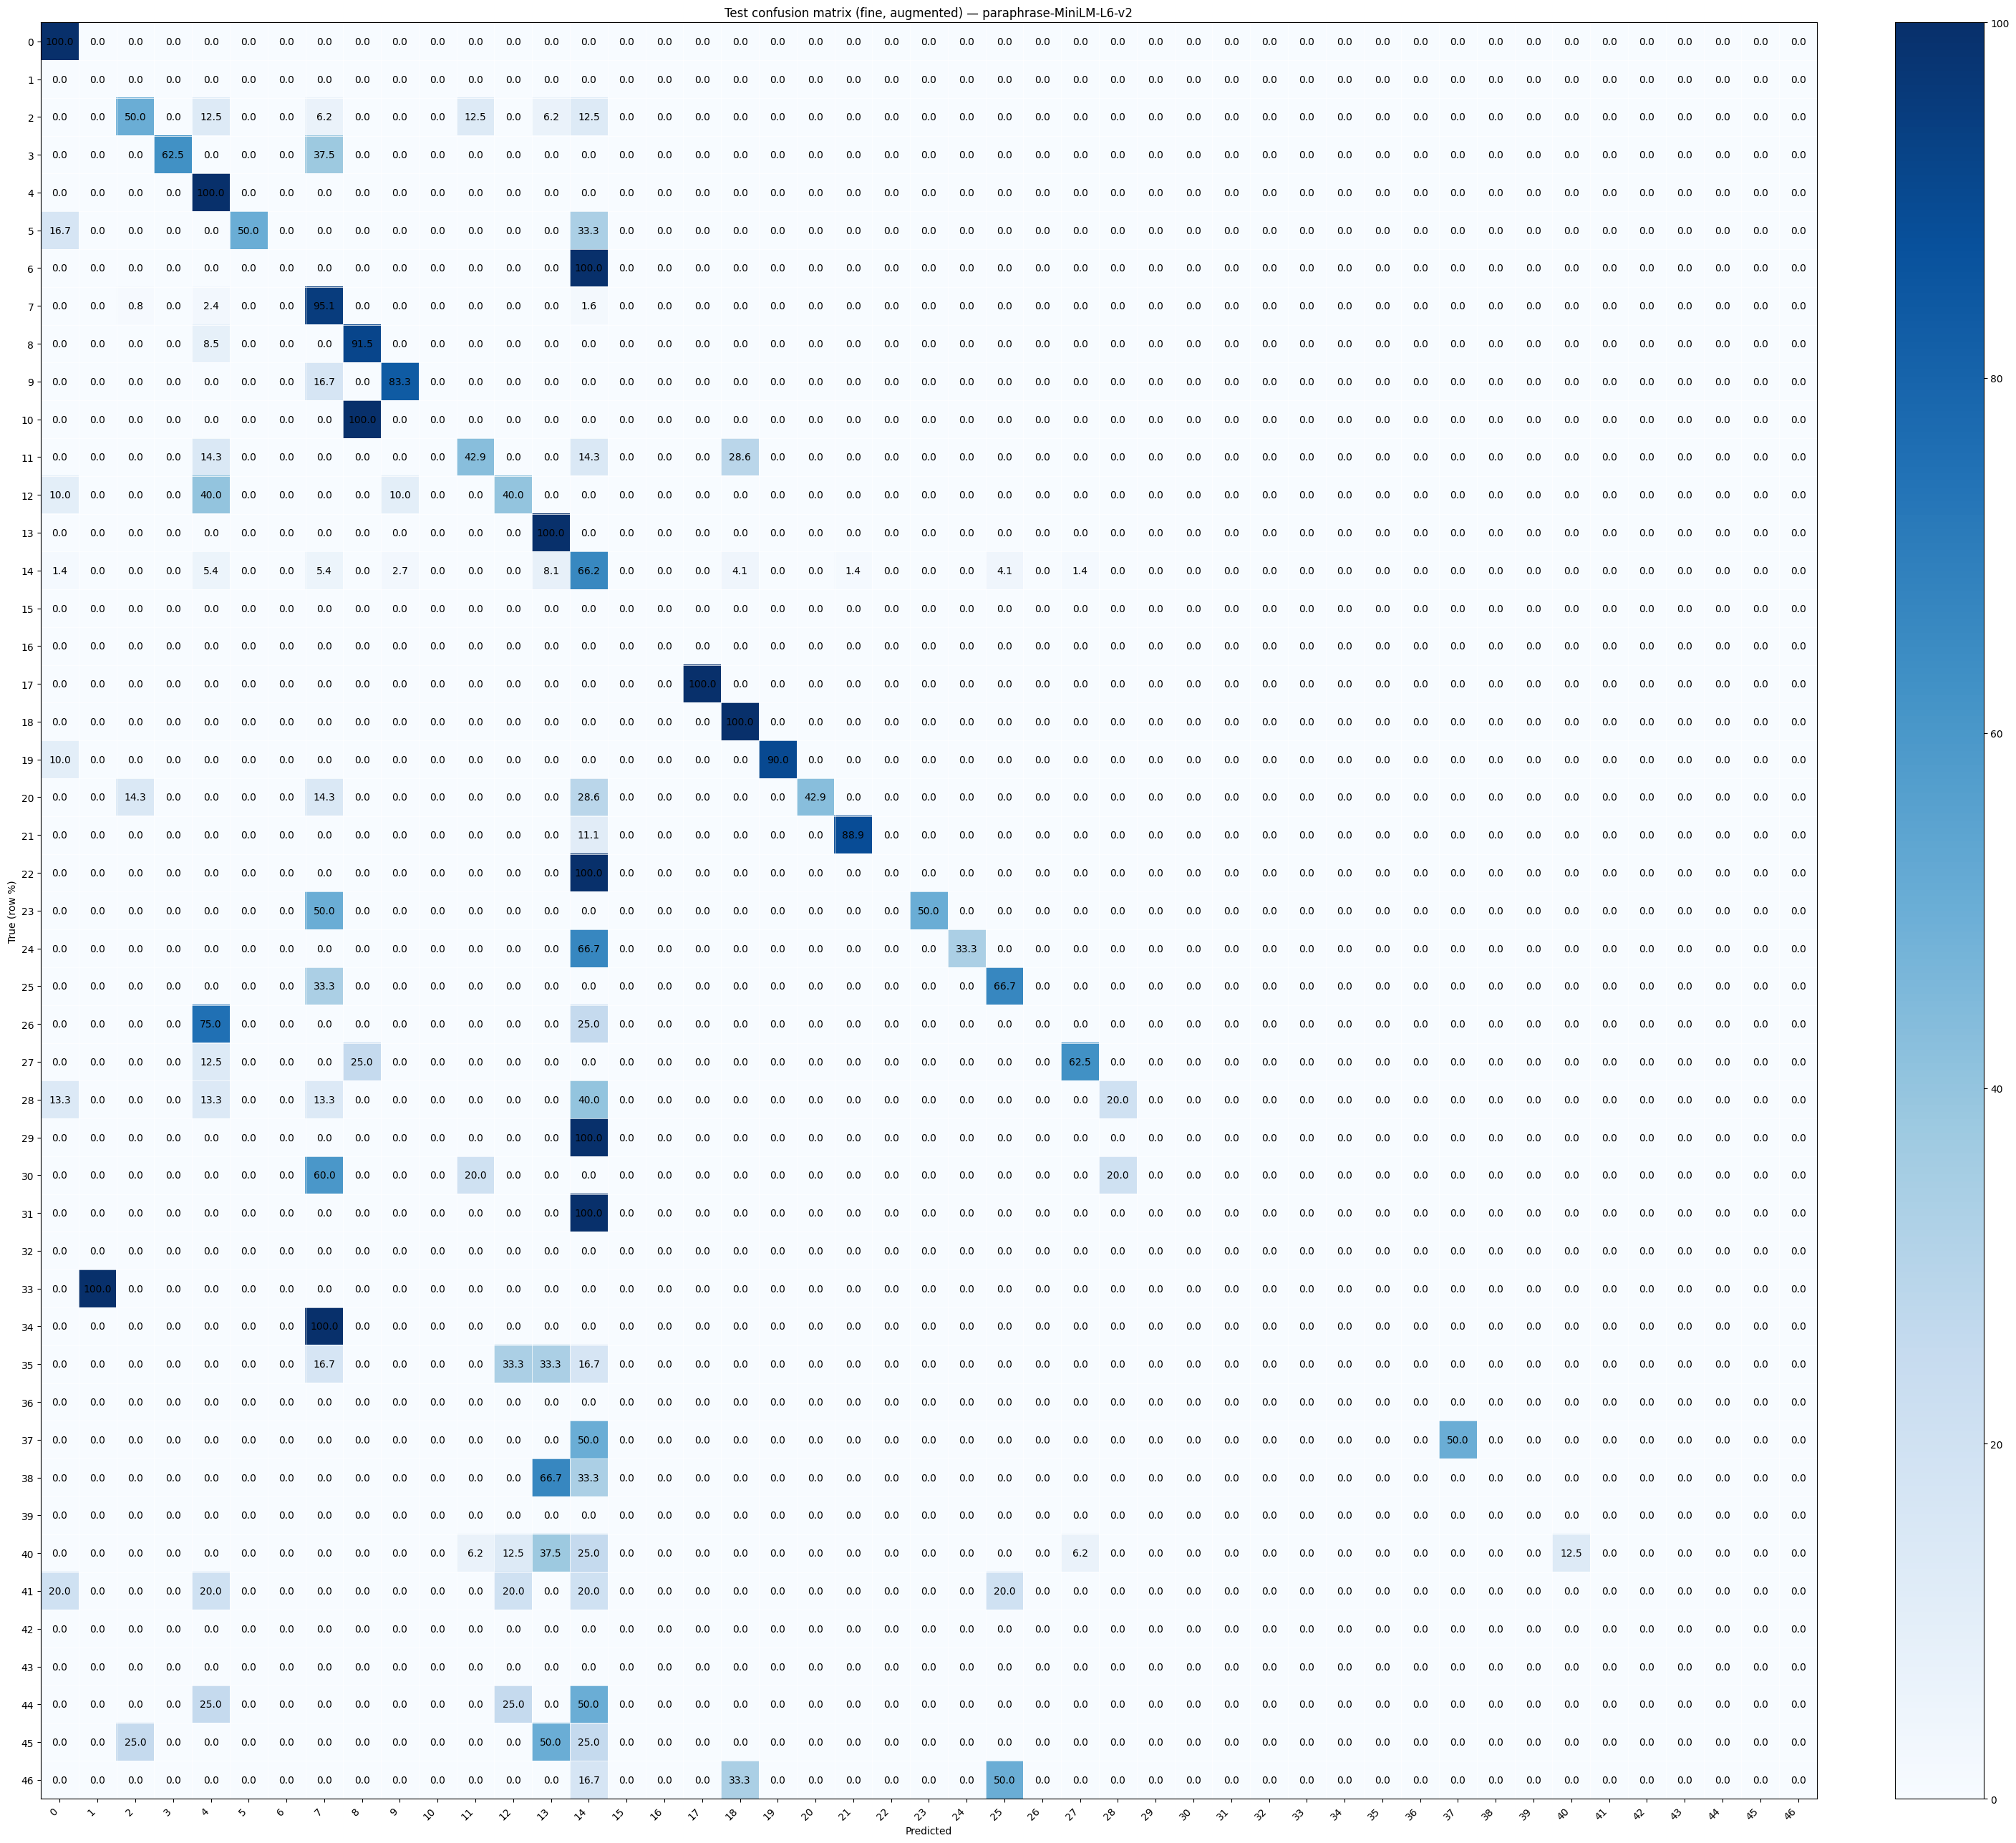

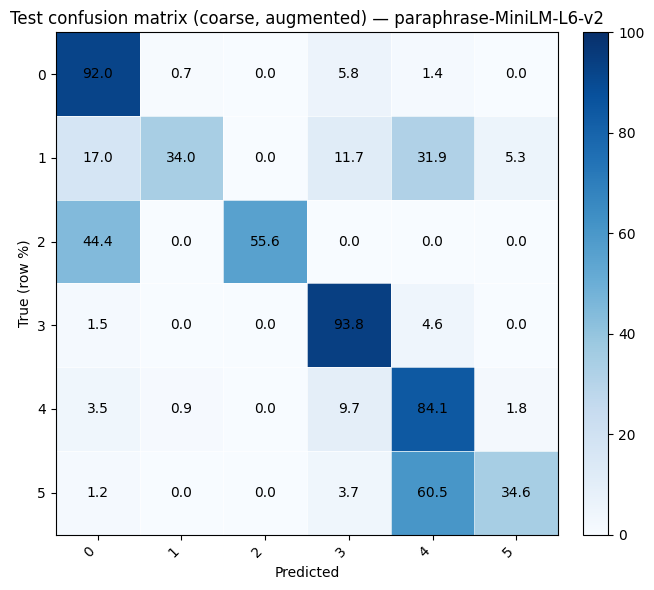

In [34]:
matrices_dir = Path("new_matrices")
matrices_dir.mkdir(parents=True, exist_ok=True)

for model_name in embedding_models:
    plot_conf_mat(
        artifacts_augmented[model_name]["y_test_idx"],
        artifacts_augmented[model_name]["test_pred_idx"],
        labels=np.arange(len(class_names)),
        title=f"Test confusion matrix (fine, augmented) — {model_name}",
        save_path=matrices_dir / f"augmented_{model_name}_fine.png"
    )

    test_pred_coarse = pd.Series(artifacts_augmented[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()

    plot_conf_mat(
        y_test_coarse,
        test_pred_coarse,
        labels=class_names_coarse,
        title=f"Test confusion matrix (coarse, augmented) — {model_name}",
        save_path=matrices_dir / f"augmented_{model_name}_coarse.png"
    )
